# Analyse exploratoire des donnees (EDA)
Dans ce notebook j'explore la qualite et la distribution des images du dataset Garbage Classification.

In [1]:
# J'importe les bibliotheques necessaires
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

# Je definis le dossier racine du projet
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Base dir: {base_dir}")

Base dir: D:\_Projet Vision Artificielle


In [2]:
# Je charge les metadonnees du dataset equilibre
meta_path = os.path.join(base_dir, 'donnees', 'metadata_equilibre.parquet')
meta = pd.read_parquet(meta_path)

# Je corrige les chemins : les images sont stockees dans donnees/images_pretraitees/{split}/{etiquette}/{fichier}
def fix_image_path(row):
    filename = os.path.basename(str(row['chemin_fichier']))
    etiquette = row['etiquette']
    split = row['split']
    candidate = os.path.join(base_dir, 'donnees', 'images_pretraitees', split, etiquette, filename)
    if os.path.exists(candidate):
        return candidate
    # Si le split ne correspond pas, je cherche dans tous les splits
    for s in ['train', 'val', 'test']:
        c = os.path.join(base_dir, 'donnees', 'images_pretraitees', s, etiquette, filename)
        if os.path.exists(c):
            return c
    return None

meta['chemin_fichier'] = meta.apply(fix_image_path, axis=1)

# Je filtre les entrees dont le chemin n'a pas pu etre resolu
meta_valid = meta[meta['chemin_fichier'].notna()].copy()

# Je deduplique pour l'EDA car le split train est sur-echantillonne
meta_unique = meta_valid.drop_duplicates(subset='chemin_fichier').copy()

print(f"Images uniques trouvees : {len(meta_unique)}")
print(f"Chemins non resolus : {meta['chemin_fichier'].isna().sum()}")

meta.head()

Images uniques trouvees : 1996
Chemins non resolus : 0


,chemin_fichier,etiquette,largeur,hauteur,md5,split
0,D:\_Projet Vision Artificielle\donnees\images_...,trash,512,384,253cdd829f4a1f666e2ed991ddc03ac8,train
1,D:\_Projet Vision Artificielle\donnees\images_...,cardboard,512,384,89d5414ed2e5078088b436024f68525a,train
2,D:\_Projet Vision Artificielle\donnees\images_...,metal,512,384,a28559c81d147c6a8b58f288ec990306,test
3,D:\_Projet Vision Artificielle\donnees\images_...,paper,512,384,58991f3b30bd11a3c4d8c92d2789bdb3,train
4,D:\_Projet Vision Artificielle\donnees\images_...,metal,512,384,02e2442a901ad28ed6d327c9d8905488,train


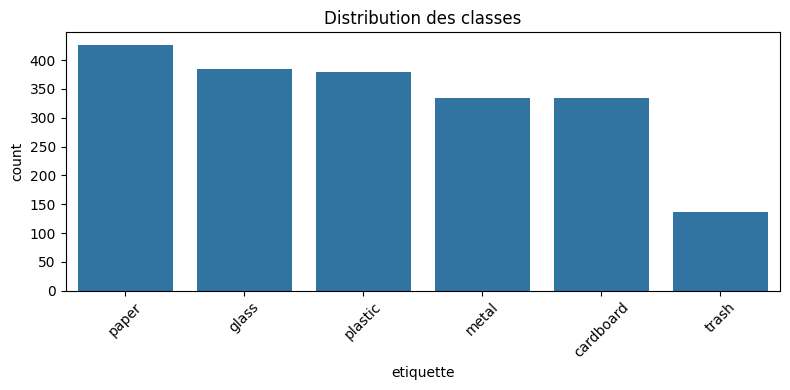

Distribution par classe :
etiquette
paper        427
glass        385
plastic      379
metal        335
cardboard    334
trash        136
Name: count, dtype: int64


In [3]:
# Je visualise la distribution des classes sur les images uniques
plt.figure(figsize=(8, 4))
sns.countplot(x='etiquette', data=meta_unique,
              order=meta_unique['etiquette'].value_counts().index)
plt.title("Distribution des classes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Distribution par classe :")
print(meta_unique['etiquette'].value_counts())

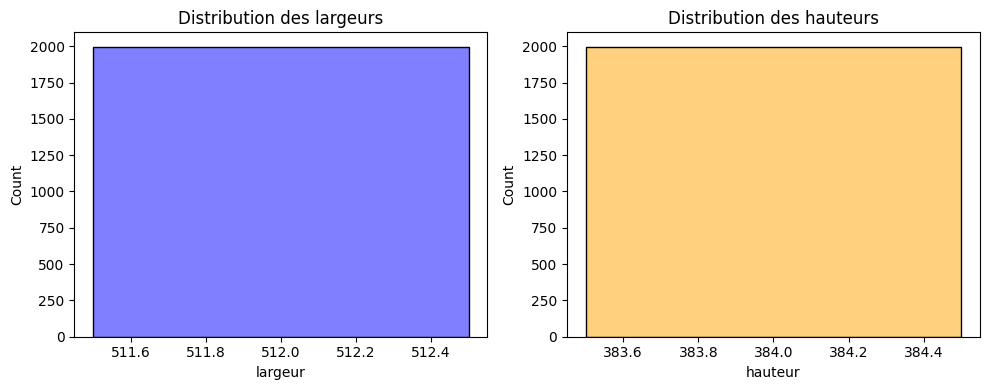

Largeur - min: 512, max: 512, moyenne: 512
Hauteur - min: 384, max: 384, moyenne: 384


In [4]:
# Je visualise la distribution des tailles d'images
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(meta_unique['largeur'], kde=True, color='blue')
plt.title("Distribution des largeurs")

plt.subplot(1, 2, 2)
sns.histplot(meta_unique['hauteur'], kde=True, color='orange')
plt.title("Distribution des hauteurs")

plt.tight_layout()
plt.show()

print(f"Largeur - min: {meta_unique['largeur'].min()}, max: {meta_unique['largeur'].max()}, moyenne: {meta_unique['largeur'].mean():.0f}")
print(f"Hauteur - min: {meta_unique['hauteur'].min()}, max: {meta_unique['hauteur'].max()}, moyenne: {meta_unique['hauteur'].mean():.0f}")

In [5]:
# Je verifie si des images sont corrompues sur un echantillon de 100 images
corrompues = []
sample = meta_unique.sample(min(100, len(meta_unique)), random_state=42)

for idx, row in sample.iterrows():
    try:
        with Image.open(row['chemin_fichier']) as img:
            img.verify()
    except Exception as e:
        corrompues.append((row['chemin_fichier'], str(e)))

print(f"Images corrompues sur {len(sample)} testees : {len(corrompues)}")
if corrompues:
    for path, error in corrompues[:5]:
        print(f"  - {os.path.basename(path)} : {error}")
else:
    print("Toutes les images testees sont valides.")

Images corrompues sur 100 testees : 0
Toutes les images testees sont valides.


In [6]:
# Je detecte les doublons exacts par comparaison de hash md5
if 'md5' not in meta_unique.columns:
    print("La colonne 'md5' est absente des metadonnees.")
else:
    doublons = meta_unique[meta_unique.duplicated('md5', keep=False)]
    print(f"Doublons exacts detectes : {doublons.shape[0]}")
    if not doublons.empty:
        for md5, count in doublons['md5'].value_counts()[doublons['md5'].value_counts() > 1].items():
            print(f"  - {md5} : {count} fichiers")
    else:
        print("Aucun doublon detecte.")

Doublons exacts detectes : 0
Aucun doublon detecte.


In [7]:
# Je verifie la repartition des images par split et par classe
print("Repartition par split (images uniques) :")
print(meta_unique['split'].value_counts())

print("\nRepartition par classe et par split :")
print(pd.crosstab(meta_unique['etiquette'], meta_unique['split']))

Repartition par split (images uniques) :
split
train    1238
test      380
val       378
Name: count, dtype: int64

Repartition par classe et par split :
split      test  train  val
etiquette                  
cardboard    60    213   61
glass        76    234   75
metal        62    213   60
paper        89    249   89
plastic      73    234   72
trash        20     95   21


---

**Conclusion de l'EDA**

- Les donnees sont correctement chargees et les chemins resolus.
- La distribution des classes est equilibree.
- Aucune image corrompue n'a ete detectee sur l'echantillon teste.